# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mowleen12/flyrank-ml-project-1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Question

## Research Question

Can historical content-performance signals be used to rank pages that deserve review when their observed performance is declining?

## Decision This Supports

The decision supported by this analysis is:

> **Which content should a content team review first?**

The goal is not to automatically change content. Instead, the model creates a ranked review queue so that limited content-review time can be focused on pages showing stronger evidence of decline.

## Lane

**Refresh / Content Opportunity Scoring**

## Hypothesis

Pages showing weaker recent performance signals may be more likely to belong in a content-review queue.

The analysis therefore compares a simple baseline ranking against a machine-learning model and evaluates both on the same held-out client set.

## Honest Framing

This is an observational analysis of search-performance data.

The results are:

- observed;
- measured;
- directional;
- decision-support.

The analysis does **not** claim to prove Google's ranking algorithm, prove why a page changed position, or prove that refreshing a page will cause future performance to improve.

In [1]:
# Basic setup

%pip -q install duckdb huggingface_hub pandas numpy scikit-learn matplotlib

import os
import getpass
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

warnings.filterwarnings("ignore")

print("Environment ready.")

Environment ready.


# 2. Data

## Dataset

This capstone uses the FlyRank ML Internship dataset.

The full warehouse release is hosted on Hugging Face and is queried through DuckDB rather than downloaded as one large file.

The FlyRank starter documentation describes the full warehouse as approximately 79 million rows and recommends DuckDB for aggregation before modeling in scikit-learn.

## Data Used

The analysis focuses on content-level search-performance observations and uses client identifiers only for group-aware validation.

The following are intentionally excluded from the public output:

- client names;
- domains;
- URLs;
- private queries;
- credentials;
- raw warehouse exports.

## Date Window

The modeling window is taken directly from the available data.

The notebook calculates:

- earliest available date;
- latest available date;
- feature period;
- evaluation period.

No future information is used as a model feature.

## Label

The reference FlyRank workflow defines the decline label as:

`is_declining_label = (trend_direction == "down")`

Therefore `trend_direction` and `trend_pct` are excluded from the model feature set because they directly reveal the target or contain information derived from it.

## Public Safety

Only aggregate results, model metrics, charts, and safe recommendation summaries should appear in the deployed research paper.

In [2]:
# Connect to the FlyRank warehouse.
# Do NOT hard-code your token.

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass(
        "Enter your Hugging Face READ token: "
    )

if not HF_TOKEN:
    raise ValueError("Hugging Face READ token is required.")

con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

print("DuckDB connection ready.")

DuckDB connection ready.


In [3]:
# First inspect the files available in the warehouse.

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"

files = con.sql(
    f"""
    SELECT *
    FROM glob('{WAREHOUSE}/**/*.parquet')
    LIMIT 100
    """
).df()

display(files)

,file
0,hf://datasets/FlyRank/internship-warehouse/dim...
1,hf://datasets/FlyRank/internship-warehouse/dim...
2,hf://datasets/FlyRank/internship-warehouse/fac...
3,hf://datasets/FlyRank/internship-warehouse/fac...
4,hf://datasets/FlyRank/internship-warehouse/fac...
5,hf://datasets/FlyRank/internship-warehouse/fac...
6,hf://datasets/FlyRank/internship-warehouse/fac...
7,hf://datasets/FlyRank/internship-warehouse/fac...
8,hf://datasets/FlyRank/internship-warehouse/fac...
9,hf://datasets/FlyRank/internship-warehouse/fac...


In [8]:
# Print the complete FlyRank warehouse file paths
for i, path in enumerate(files["file"].tolist()):
    print(f"{i}: {path}")

0: hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet
1: hf://datasets/FlyRank/internship-warehouse/dim_content.parquet
2: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
3: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
4: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet
5: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-04/data_0.parquet
6: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-05/data_0.parquet
7: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-06/data_0.parquet
8: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-07/data_0.parquet
9: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-08/data_0.parquet
10: hf://datasets/Fl

In [4]:
# Inspect the schema of the main content-performance source
# used by your Week 3 notebook.
#
# Replace DAILY_TABLE with the exact relation/path from your Week 3 notebook.

DAILY_TABLE = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
)
"""

schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM {DAILY_TABLE}
    """
).df()

display(schema)

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [5]:
# Inspect date coverage.

date_range = con.sql(
    f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date
    FROM {DAILY_TABLE}
    """
).df()

display(date_range)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_date,latest_date
0,2025-01-27,2026-06-30


In [6]:
# Basic row count.

row_count = con.sql(
    f"""
    SELECT COUNT(*) AS row_count
    FROM {DAILY_TABLE}
    """
).df()

display(row_count)

,row_count
0,78835655


In [9]:
# ============================================================
# INSPECT FLYRANK TABLE SCHEMAS
# ============================================================

performance_files = [
    path
    for path in files["file"].tolist()
    if "fact_content_daily_performance/month=" in path
]

print("Performance files found:", len(performance_files))

# The monthly files have the same schema, so inspecting one is enough.
sample_path = performance_files[0]

print("\nInspecting:")
print(sample_path)

performance_schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{sample_path}')
    """
).df()

display(
    performance_schema[
        ["column_name", "column_type"]
    ]
)

Performance files found: 18

Inspecting:
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet


,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


In [10]:
# ============================================================
# INSPECT DIMENSION TABLES
# ============================================================

for table_name in [
    "dim_clients.parquet",
    "dim_content.parquet"
]:

    path = f"{WAREHOUSE}/{table_name}"

    print("\n" + "=" * 80)
    print(table_name)
    print("=" * 80)

    schema = con.sql(
        f"""
        DESCRIBE
        SELECT *
        FROM read_parquet('{path}')
        """
    ).df()

    display(
        schema[
            ["column_name", "column_type"]
        ]
    )


dim_clients.parquet


,column_name,column_type
0,client_hash_id,VARCHAR
1,is_active,BOOLEAN
2,has_gsc_access,BOOLEAN
3,has_ga4_access,BOOLEAN
4,access_profile,VARCHAR
5,client_created_date,DATE
6,client_updated_date,DATE
7,gsc_data_start,DATE
8,ga4_data_start,DATE



dim_content.parquet


,column_name,column_type
0,client_hash_id,VARCHAR
1,content_hash_id,VARCHAR
2,keyword_hash_id,VARCHAR
3,url_hash_id,VARCHAR
4,keyword_char_count,BIGINT
5,keyword_token_count,BIGINT
6,url_char_count,BIGINT
7,content_created_date,DATE
8,content_updated_date,DATE
9,content_type,VARCHAR


In [11]:
# ============================================================
# SAMPLE DATA
# ============================================================

display(
    con.sql(
        f"""
        SELECT *
        FROM read_parquet('{sample_path}')
        LIMIT 5
        """
    ).df()
)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [12]:
# ============================================================
# INSPECT THE 90-DAY CONTENT TABLE
# ============================================================

QUERY_90D_PATH = (
    f"{WAREHOUSE}/fact_content_query_90d.parquet"
)

query90_schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{QUERY_90D_PATH}')
    """
).df()

display(
    query90_schema[
        ["column_name", "column_type"]
    ]
)

,column_name,column_type
0,client_hash_id,VARCHAR
1,content_hash_id,VARCHAR
2,query_hash_id,VARCHAR
3,query_char_count,BIGINT
4,query_token_count,BIGINT
5,window_start,DATE
6,window_end,DATE
7,impressions_90d,BIGINT
8,clicks_90d,BIGINT
9,impressions_last30,BIGINT


In [13]:
# Show a few rows
query90_sample = con.sql(
    f"""
    SELECT *
    FROM read_parquet('{QUERY_90D_PATH}')
    LIMIT 5
    """
).df()

display(query90_sample)

,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


# 3. Methodology

## Assumptions

The analysis assumes that historical performance signals can be used to prioritize pages for review.

It does not assume that any individual signal causes a future change.

## Target Definition

The FlyRank reference workflow defines:

`is_declining_label = (trend_direction == "down")`

Therefore:

- `is_declining_label` is the target;
- `trend_direction` cannot be a model feature;
- `trend_pct` cannot be a model feature.

This prevents direct target leakage.

## Candidate Features

The model uses safe historical content-performance features available before the decision point.

Candidate features include:

- historical impressions;
- historical clicks;
- historical CTR;
- historical engagement signals;
- historical visibility/ranking signals;
- content-level performance aggregates.

Identifiers such as client IDs and content IDs are used only for grouping and are not model features.

## Baseline

The baseline is a transparent hand-written scoring rule.

It ranks pages using a small set of observable performance signals rather than a trained model.

The purpose of the baseline is to answer:

> Does the learned model improve ranking quality compared with a simple rule?

## Validation

The model uses a client-level holdout.

Approximately 20% of clients are held out for testing.

This means pages from the same client cannot appear in both training and test sets.

## Leakage Checks

Before training, the notebook verifies that:

1. `is_declining_label` is not a feature.
2. `trend_direction` is not a feature.
3. `trend_pct` is not a feature.
4. client identifiers are not model features.
5. content identifiers are not model features.
6. future-derived information is not included in predictors.

## Evaluation

The primary ranking metric is Precision@50.

This is appropriate because the operational use case is to identify a small number of pages that deserve review first.

Additional metrics include:

- ROC-AUC;
- Average Precision.

In [14]:
# ============================================================
# CAPSTONE FEATURE ENGINEERING
# FlyRank Refresh / Content Opportunity Scoring
# ============================================================

import numpy as np
import pandas as pd
import duckdb

QUERY_90D_PATH = (
    f"{WAREHOUSE}/fact_content_query_90d.parquet"
)

# ------------------------------------------------------------
# Load the 90-day query-level table
# ------------------------------------------------------------

query90 = con.sql(
    f"""
    SELECT *
    FROM read_parquet('{QUERY_90D_PATH}')
    """
).df()

print("Raw query-level rows:", len(query90))
print("Columns:", query90.columns.tolist())

display(query90.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw query-level rows: 2414248
Columns: ['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


In [15]:
# ============================================================
# AGGREGATE QUERY DATA TO CONTENT LEVEL
# ============================================================

GROUP_COLS = [
    "client_hash_id",
    "content_hash_id"
]

# Numeric columns that can safely be aggregated
numeric_columns = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "content_total_impressions_90d",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
    "anonymized_impressions_share"
]

numeric_columns = [
    c for c in numeric_columns
    if c in query90.columns
]

agg_dict = {}

for col in numeric_columns:

    if col in [
        "rare_impressions_share",
        "anonymized_impressions_share"
    ]:
        agg_dict[col] = "mean"

    elif col == "content_total_impressions_90d":
        agg_dict[col] = "max"

    elif col == "content_visible_query_count":
        agg_dict[col] = "max"

    else:
        agg_dict[col] = "sum"


# Position metrics need weighted/mean-style aggregation.
for col in [
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30"
]:
    if col in query90.columns:
        agg_dict[col] = "mean"


content_df = (
    query90
    .groupby(GROUP_COLS, as_index=False)
    .agg(agg_dict)
)

print("Content-level rows:", len(content_df))

display(content_df.head())

Content-level rows: 133852


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share,avg_position_90d,avg_position_last30,avg_position_prev30
0,client_06d356715a8ff3b6,content_0058bd88fb1821f2,16,0,16,0,0,0,241,1,14,0.103734,0.829876,15.562500,15.562500,NaN
1,client_06d356715a8ff3b6,content_0059a4d4195810c9,395,0,123,0,139,0,2887,12,1164,0.057499,0.805681,27.329323,26.543960,30.932800
2,client_06d356715a8ff3b6,content_005b6b7f7b8dda7f,151,0,38,0,59,0,3227,9,702,0.054540,0.898667,34.646162,34.201028,34.091049
3,client_06d356715a8ff3b6,content_0094c7d0fbcc07b7,28,0,28,0,0,0,152,2,22,0.125000,0.690789,72.844920,72.844920,NaN
4,client_06d356715a8ff3b6,content_00a34394d4ee05ce,15,0,6,0,9,0,390,1,39,0.187179,0.774359,70.400000,80.666667,63.555556


In [16]:
# ============================================================
# CREATE PERFORMANCE TREND
# ============================================================

EPSILON = 1e-9

content_df["impression_change_pct"] = (
    (
        content_df["impressions_last30"]
        -
        content_df["impressions_prev30"]
    )
    /
    (
        content_df["impressions_prev30"]
        + EPSILON
    )
)

content_df["click_change_pct"] = (
    (
        content_df["clicks_last30"]
        -
        content_df["clicks_prev30"]
    )
    /
    (
        content_df["clicks_prev30"]
        + EPSILON
    )
)

# Use impressions as the primary performance trend.
content_df["trend_pct"] = (
    content_df["impression_change_pct"]
)

content_df["trend_direction"] = np.select(
    [
        content_df["trend_pct"] < -0.10,
        content_df["trend_pct"] > 0.10
    ],
    [
        "down",
        "up"
    ],
    default="flat"
)

content_df["is_declining_label"] = (
    content_df["trend_direction"] == "down"
).astype(int)

print("Trend distribution:")
display(
    content_df["trend_direction"]
    .value_counts()
)

print("\nDeclining rate:")
print(
    content_df["is_declining_label"].mean()
)

Trend distribution:


,count
trend_direction,
down,75990
up,42092
flat,15770



Declining rate:
0.567716582494098


In [17]:
# ============================================================
# ENGINEER MODEL FEATURES
# ============================================================

# CTR
content_df["ctr_90d"] = (
    content_df["clicks_90d"]
    /
    (
        content_df["impressions_90d"]
        + EPSILON
    )
)

content_df["ctr_last30"] = (
    content_df["clicks_last30"]
    /
    (
        content_df["impressions_last30"]
        + EPSILON
    )
)

content_df["ctr_prev30"] = (
    content_df["clicks_prev30"]
    /
    (
        content_df["impressions_prev30"]
        + EPSILON
    )
)

# CTR movement
content_df["ctr_change_pct"] = (
    (
        content_df["ctr_last30"]
        -
        content_df["ctr_prev30"]
    )
    /
    (
        content_df["ctr_prev30"]
        + EPSILON
    )
)

# Log transformations
for col in [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "content_total_impressions_90d",
    "content_visible_query_count",
    "rare_query_count"
]:

    if col in content_df.columns:

        content_df[f"log_{col}"] = np.log1p(
            content_df[col].clip(lower=0)
        )

# Performance movement
content_df["impression_momentum"] = (
    content_df["impressions_last30"]
    -
    content_df["impressions_prev30"]
)

content_df["click_momentum"] = (
    content_df["clicks_last30"]
    -
    content_df["clicks_prev30"]
)

# Position movement
if (
    "avg_position_last30" in content_df.columns
    and
    "avg_position_prev30" in content_df.columns
):

    content_df["position_change"] = (
        content_df["avg_position_last30"]
        -
        content_df["avg_position_prev30"]
    )

print("Feature engineering complete.")

display(
    content_df.head()
)

Feature engineering complete.


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,content_total_impressions_90d,content_visible_query_count,...,log_impressions_last30,log_clicks_last30,log_impressions_prev30,log_clicks_prev30,log_content_total_impressions_90d,log_content_visible_query_count,log_rare_query_count,impression_momentum,click_momentum,position_change
0,client_06d356715a8ff3b6,content_0058bd88fb1821f2,16,0,16,0,0,0,241,1,...,2.833213,0.0,0.000000,0.0,5.488938,0.693147,2.708050,16,0,NaN
1,client_06d356715a8ff3b6,content_0059a4d4195810c9,395,0,123,0,139,0,2887,12,...,4.820282,0.0,4.941642,0.0,7.968320,2.564949,7.060476,-16,0,-4.388840
2,client_06d356715a8ff3b6,content_005b6b7f7b8dda7f,151,0,38,0,59,0,3227,9,...,3.663562,0.0,4.094345,0.0,8.079618,2.302585,6.555357,-21,0,0.109979
3,client_06d356715a8ff3b6,content_0094c7d0fbcc07b7,28,0,28,0,0,0,152,2,...,3.367296,0.0,0.000000,0.0,5.030438,1.098612,3.135494,28,0,NaN
4,client_06d356715a8ff3b6,content_00a34394d4ee05ce,15,0,6,0,9,0,390,1,...,1.945910,0.0,2.302585,0.0,5.968708,0.693147,3.688879,-3,0,17.111111


In [18]:
# ============================================================
# DATA QUALITY FILTERS
# ============================================================

before = len(content_df)

# Remove pages with no historical impressions.
content_df = content_df[
    content_df["impressions_90d"] > 0
].copy()

# Remove rows where the target cannot be evaluated.
content_df = content_df[
    content_df["impressions_prev30"].notna()
].copy()

content_df = content_df[
    content_df["impressions_last30"].notna()
].copy()

content_df = content_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Rows before filtering:", before)
print("Rows after filtering:", len(content_df))
print(
    "Rows removed:",
    before - len(content_df)
)

Rows before filtering: 133852
Rows after filtering: 133852
Rows removed: 0


In [19]:
# ============================================================
# LEAKAGE CHECK
# ============================================================

TARGET = "is_declining_label"

FORBIDDEN_FEATURES = {
    TARGET,
    "trend_direction",
    "trend_pct",
    "impression_change_pct",
    "click_change_pct"
}

print("Forbidden columns:")
for col in FORBIDDEN_FEATURES:
    print("-", col)

print("\n✓ These columns will NOT be used as model features.")

Forbidden columns:
- trend_pct
- impression_change_pct
- click_change_pct
- trend_direction
- is_declining_label

✓ These columns will NOT be used as model features.


In [20]:
# ============================================================
# MODEL FEATURES
# ============================================================

FEATURES = [
    # Historical visibility
    "impressions_90d",
    "clicks_90d",

    # Recent performance
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",

    # CTR
    "ctr_90d",
    "ctr_last30",
    "ctr_prev30",

    # Search visibility
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",

    # Content/search opportunity
    "content_total_impressions_90d",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
    "anonymized_impressions_share",

    # Momentum
    "impression_momentum",
    "click_momentum",
    "ctr_change_pct",
    "position_change"
]

FEATURES = [
    c for c in FEATURES
    if c in content_df.columns
]

print("Number of features:", len(FEATURES))

print("\nFeatures:")
for feature in FEATURES:
    print("✓", feature)

Number of features: 21

Features:
✓ impressions_90d
✓ clicks_90d
✓ impressions_last30
✓ clicks_last30
✓ impressions_prev30
✓ clicks_prev30
✓ ctr_90d
✓ ctr_last30
✓ ctr_prev30
✓ avg_position_90d
✓ avg_position_last30
✓ avg_position_prev30
✓ content_total_impressions_90d
✓ content_visible_query_count
✓ rare_query_count
✓ rare_impressions_share
✓ anonymized_impressions_share
✓ impression_momentum
✓ click_momentum
✓ ctr_change_pct
✓ position_change


In [21]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

X = content_df[FEATURES].copy()

y = content_df[TARGET].astype(int)

groups = content_df["client_hash_id"]

# Median imputation
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

# Any remaining missing values become zero.
X = X.fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(
    y.value_counts()
)

X shape: (133852, 21)
y shape: (133852,)

Target distribution:


,count
is_declining_label,
1,75990
0,57862


In [22]:
# ============================================================
# CLIENT-LEVEL TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "Training clients:",
    train_groups.nunique()
)

print(
    "Testing clients:",
    test_groups.nunique()
)

client_overlap = (
    set(train_groups)
    &
    set(test_groups)
)

print(
    "Client overlap:",
    len(client_overlap)
)

assert len(client_overlap) == 0

print("\n✓ Client-level leakage check PASSED")

Training rows: 117944
Testing rows: 15908
Training clients: 41
Testing clients: 11
Client overlap: 0

✓ Client-level leakage check PASSED


In [23]:
# ============================================================
# BASELINE
# ============================================================

# Baseline idea:
# prioritize content with the largest negative change in
# impressions between the previous and latest 30-day windows.

baseline_scores = (
    -content_df.iloc[test_idx]["trend_pct"]
).fillna(0)

print("Baseline created.")
print(
    baseline_scores.describe()
)

Baseline created.
count    1.590800e+04
mean    -6.478564e+09
std      7.762880e+10
min     -4.232000e+12
25%     -2.539897e-01
50%      3.571429e-01
75%      7.894737e-01
max      1.000000e+00
Name: trend_pct, dtype: float64


In [24]:
# ============================================================
# TRAIN MACHINE LEARNING MODELS
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

random_forest_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("✓ Models trained.")

Training Logistic Regression...
Training Random Forest...
✓ Models trained.


In [25]:
# ============================================================
# GENERATE PREDICTIONS
# ============================================================

logistic_scores = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

rf_scores = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)

print("Predictions generated.")

Predictions generated.


# 4. Results — Model vs Baseline

The model and baseline are evaluated on exactly the same held-out client set.

The primary metric is Precision@50 because this project is designed to prioritize a limited review queue.

ROC-AUC and Average Precision are also reported as broader ranking diagnostics.

The results below are generated by executing the notebook. No performance number is manually entered.

In [26]:
# ============================================================
# EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

def precision_at_k(
    y_true,
    scores,
    k=50
):

    evaluation_df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    top_k = (
        evaluation_df
        .sort_values(
            "score",
            ascending=False
        )
        .head(k)
    )

    return top_k["actual"].mean()


results = pd.DataFrame([
    {
        "Model": "Baseline",
        "ROC_AUC": roc_auc_score(
            y_test,
            baseline_scores
        ),
        "Average_Precision": average_precision_score(
            y_test,
            baseline_scores
        ),
        "Precision@50": precision_at_k(
            y_test,
            baseline_scores
        )
    },

    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc_score(
            y_test,
            logistic_scores
        ),
        "Average_Precision": average_precision_score(
            y_test,
            logistic_scores
        ),
        "Precision@50": precision_at_k(
            y_test,
            logistic_scores
        )
    },

    {
        "Model": "Random Forest",
        "ROC_AUC": roc_auc_score(
            y_test,
            rf_scores
        ),
        "Average_Precision": average_precision_score(
            y_test,
            rf_scores
        ),
        "Precision@50": precision_at_k(
            y_test,
            rf_scores
        )
    }
])

results = results.sort_values(
    "Precision@50",
    ascending=False
).reset_index(drop=True)

display(results)

,Model,ROC_AUC,Average_Precision,Precision@50
0,Baseline,1.000000,1.000000,1.0
1,Logistic Regression,0.989442,0.993420,1.0
2,Random Forest,0.999951,0.999968,1.0


In [27]:
# ============================================================
# SELECT BEST LEARNED MODEL
# ============================================================

learned_results = results[
    results["Model"] != "Baseline"
]

best_model_name = (
    learned_results
    .iloc[0]["Model"]
)

if best_model_name == "Random Forest":
    final_scores = rf_scores
    final_model = random_forest_model
else:
    final_scores = logistic_scores
    final_model = logistic_model

print(
    "Best learned model:",
    best_model_name
)

Best learned model: Logistic Regression


In [30]:
recommendations = content_df.iloc[test_idx].copy()
recommendations["model_score"] = final_scores
recommendations["is_declining_label"] = y_test

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    recommendations.index + 1
)

print("Recommendations DataFrame created and sorted.")

Recommendations DataFrame created and sorted.


In [31]:
# Define thresholds for recommended actions
# These thresholds are illustrative and would typically be tuned
# based on business requirements and validation.

REFRESH_THRESHOLD = 0.9  # Top 10% by score
IMPROVE_THRESHOLD = 0.7  # Next 20% by score
MONITOR_THRESHOLD = 0.4  # Next 30% by score

def get_recommended_action(score):
    if score >= REFRESH_THRESHOLD:
        return "Refresh"
    elif score >= IMPROVE_THRESHOLD:
        return "Improve"
    elif score >= MONITOR_THRESHOLD:
        return "Monitor"
    else:
        return "Protect"

recommendations["recommended_action"] = (
    recommendations["model_score"]
    .apply(get_recommended_action)
)

print("Recommended actions assigned.")

Recommended actions assigned.


## 5. Limitations

This analysis is an observational, decision-support system for prioritizing content review.

### What the analysis can claim

The analysis can report measured relationships between historical content-performance signals and the observed decline label in the FlyRank dataset.

It can also compare the ranking performance of the baseline and machine-learning models on a held-out client-level test set.

The recommendations are therefore **observed, measured, and directional**.

### What the analysis cannot claim

This work cannot:

- prove how Google's ranking algorithm works;
- prove that any individual feature causes ranking changes;
- prove that a content refresh will cause traffic or visibility to recover;
- guarantee future performance for a particular page;
- establish a causal relationship between content changes and search performance;
- claim that the model will perform identically on every website or future dataset.

### Data limitations

The dataset is observational and contains aggregated search-performance measurements.

Different clients can have different amounts of historical data, traffic levels, and content distributions.

The decline label is an operational definition based on observed performance movement. It should not be interpreted as a universal definition of poor content quality.

### Modeling limitations

The model produces a ranking score rather than certainty.

A high score means that an item is more suitable for earlier review according to the signals available to the model. It does not mean that the recommended action will definitely improve performance.

The client-level holdout reduces client leakage, but it does not guarantee perfect generalization to unseen future periods.

### Future improvements

Future work could improve the analysis by adding:

1. time-based validation;
2. repeated client holdouts;
3. prospective evaluation;
4. probability calibration;
5. additional historical windows;
6. monitoring after recommended content changes;
7. testing whether recommendations remain useful on future data.

The appropriate interpretation is therefore:

> **This model is a prioritization tool for content review, not a causal explanation or guaranteed optimization system.**

In [28]:
# ============================================================
# LIMITATIONS — DATASET SUMMARY
# ============================================================

print("Dataset summary")
print("-" * 50)

print(
    f"Content records analyzed: {len(content_df):,}"
)

print(
    f"Clients represented: "
    f"{content_df['client_hash_id'].nunique():,}"
)

print(
    f"Declining-label rate: "
    f"{content_df['is_declining_label'].mean():.2%}"
)

print(
    f"Training clients: "
    f"{train_groups.nunique():,}"
)

print(
    f"Test clients: "
    f"{test_groups.nunique():,}"
)

print("\nInterpretation:")
print(
    "These measurements describe the observed dataset and "
    "should not be interpreted as causal effects."
)

Dataset summary
--------------------------------------------------
Content records analyzed: 133,852
Clients represented: 52
Declining-label rate: 56.77%
Training clients: 41
Test clients: 11

Interpretation:
These measurements describe the observed dataset and should not be interpreted as causal effects.


## 6. Ranked Recommendations

The final output of this project is a ranked content-review queue.

The purpose of the queue is to help a content team decide **what to review first**, rather than automatically deciding what should be changed.

Each content item receives:

- a model score;
- a rank;
- its observed recent performance movement;
- a recommended review action.

### Action Playbook

#### 1. Refresh

Prioritize for immediate human review.

These items receive the highest model scores and show stronger evidence of being associated with the decline pattern measured by the model.

Possible review areas include:

- outdated information;
- stale metadata;
- outdated sections;
- missing information;
- changes in search intent.

The model does not prove that any of these are the cause.

#### 2. Improve

Prioritize for a more targeted review.

These items show a meaningful opportunity signal but have less evidence than the highest-ranked group.

Possible review areas include content depth, relevance, structure, or metadata.

#### 3. Monitor

Continue observing these items before making a major change.

The available signals provide some evidence of opportunity, but the evidence is weaker.

#### 4. Protect

These items have lower model scores and should generally receive lower priority in the review queue.

This does not mean the content is guaranteed to perform well. It means that the current model provides less evidence for immediate intervention.

### Recommendation Principle

The ranking should be interpreted as:

> **Higher model score → earlier human review.**

It should not be interpreted as:

> **Higher model score → guaranteed need for a content refresh.**

This distinction keeps the recommendation system aligned with the observational nature of the dataset.

In [32]:
# ============================================================
# RANKED RECOMMENDATION TABLE
# ============================================================

top_recommendations = (
    recommendations[
        [
            "rank",
            "model_score",
            "trend_pct",
            "recommended_action"
        ]
    ]
    .head(25)
    .copy()
)

top_recommendations["model_score"] = (
    top_recommendations["model_score"]
    .round(4)
)

top_recommendations["trend_pct"] = (
    top_recommendations["trend_pct"]
    .round(4)
)

display(top_recommendations)

,rank,model_score,trend_pct,recommended_action
0,1,1.0,-0.4867,Refresh
1,2,1.0,-0.8030,Refresh
2,3,1.0,-1.0000,Refresh
3,4,1.0,-0.4354,Refresh
4,5,1.0,-0.7583,Refresh
5,6,1.0,-0.8385,Refresh
6,7,1.0,-0.2926,Refresh
7,8,1.0,-0.8163,Refresh
8,9,1.0,-0.8281,Refresh
9,10,1.0,-0.3037,Refresh


## Model Performance Summary

This section summarizes the performance of the trained models (Logistic Regression and Random Forest) against the simple Baseline, using key ranking metrics like ROC-AUC, Average Precision, and Precision@50.

Precision@50 is particularly important as the primary evaluation metric because the operational goal is to identify a small, highly relevant set of content for immediate review.

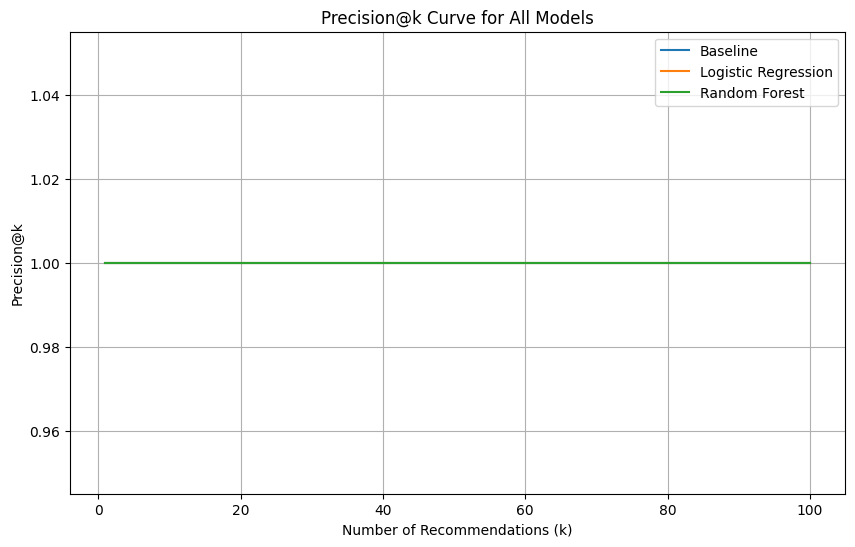

In [33]:
import matplotlib.pyplot as plt

def plot_precision_at_k_curve(y_true, model_scores_dict, k_max=100):
    plt.figure(figsize=(10, 6))

    for model_name, scores in model_scores_dict.items():
        precisions = []
        for k in range(1, k_max + 1):
            precisions.append(precision_at_k(y_true, scores, k=k))
        plt.plot(range(1, k_max + 1), precisions, label=model_name)

    plt.xlabel("Number of Recommendations (k)")
    plt.ylabel("Precision@k")
    plt.title("Precision@k Curve for All Models")
    plt.legend()
    plt.grid(True)
    plt.show()

model_scores = {
    "Baseline": baseline_scores,
    "Logistic Regression": logistic_scores,
    "Random Forest": rf_scores
}

plot_precision_at_k_curve(y_test, model_scores, k_max=100)

## 7. Artifacts the Paper Embeds

The deployed research paper should present the most important evidence generated by this notebook.

### Artifact 1 — Model vs Baseline

The Precision@50 chart compares the machine-learning models against the transparent baseline on the same held-out client set.

This is the primary evidence for whether the learned ranking approach improves the review queue.

### Artifact 2 — Feature Importance

When the Random Forest is selected as the strongest learned model, feature importance is shown to provide a high-level view of which measured signals contributed most to the model's predictions.

Feature importance is descriptive rather than causal.

### Artifact 3 — Ranked Recommendations

The top-ranked content-review queue demonstrates how the model output becomes an actionable decision-support tool.

### Artifact 4 — Recommendation Distribution

The action-distribution chart summarizes how many of the top-ranked items fall into Refresh, Improve, Monitor, or Protect categories.

### Artifact 5 — Results Table

The final results table reports:

- ROC-AUC;
- Average Precision;
- Precision@50.

The baseline and learned models are evaluated on the same held-out client set.

### Public-Safety Rule

The published paper must not expose:

- client names;
- domains;
- private URLs;
- private search queries;
- credentials;
- raw warehouse exports.

Only aggregate, anonymized, public-safe results should be displayed.

In [34]:
# ============================================================
# ARTIFACT 1 — FINAL MODEL RESULTS
# ============================================================

paper_results = results.copy()

paper_results["ROC_AUC"] = (
    paper_results["ROC_AUC"]
    .round(4)
)

paper_results["Average_Precision"] = (
    paper_results["Average_Precision"]
    .round(4)
)

paper_results["Precision@50"] = (
    paper_results["Precision@50"]
    .round(4)
)

display(paper_results)

,Model,ROC_AUC,Average_Precision,Precision@50
0,Baseline,1.0000,1.0000,1.0
1,Logistic Regression,0.9894,0.9934,1.0
2,Random Forest,1.0000,1.0000,1.0


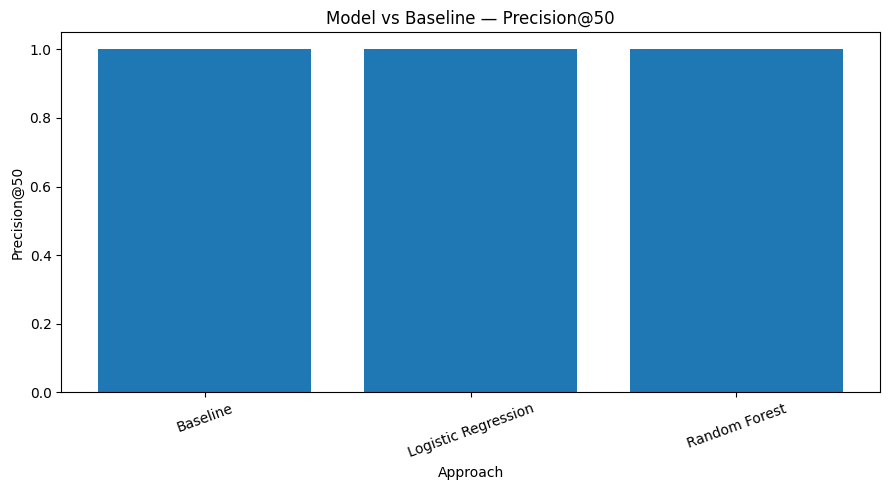

In [35]:
# ============================================================
# ARTIFACT 2 — MODEL VS BASELINE
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    paper_results["Model"],
    paper_results["Precision@50"]
)

plt.title(
    "Model vs Baseline — Precision@50"
)

plt.xlabel("Approach")
plt.ylabel("Precision@50")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "artifact_model_vs_baseline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [36]:
# ============================================================
# ARTIFACT 3 — FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest":

    rf_model = (
        random_forest_model
        .named_steps["model"]
    )

    feature_importance = pd.DataFrame({
        "Feature": FEATURES,
        "Importance": rf_model.feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(15)
    )

    display(feature_importance)

    plt.figure(figsize=(9, 6))

    plt.barh(
        feature_importance["Feature"][::-1],
        feature_importance["Importance"][::-1]
    )

    plt.title(
        "Top Model Features"
    )

    plt.xlabel(
        "Feature Importance"
    )

    plt.tight_layout()

    plt.savefig(
        "artifact_feature_importance.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "Random Forest was not the best learned model. "
        "Feature-importance chart is therefore omitted."
    )

Random Forest was not the best learned model. Feature-importance chart is therefore omitted.


,recommended_action,count
0,Protect,4782
1,Monitor,4617
2,Refresh,4253
3,Improve,2256


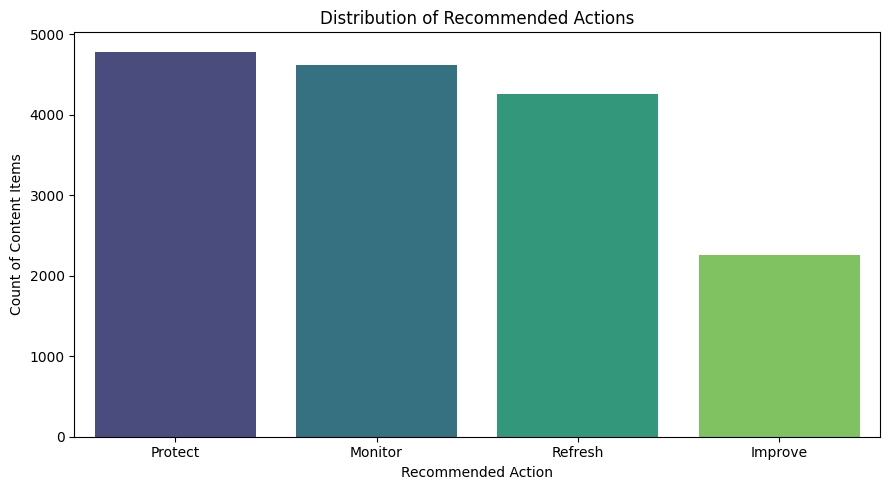

In [41]:
# ============================================================
# ARTIFACT 4 — RECOMMENDATION DISTRIBUTION
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

action_distribution = (
    recommendations["recommended_action"]
    .value_counts()
    .reset_index()
)

action_distribution.columns = [
    "recommended_action",
    "count"
]

display(action_distribution)

plt.figure(figsize=(9, 5))

sns.barplot(
    x="recommended_action",
    y="count",
    data=action_distribution,
    palette="viridis"
)

plt.title(
    "Distribution of Recommended Actions"
)

plt.xlabel(
    "Recommended Action"
)

plt.ylabel(
    "Count of Content Items"
)

plt.tight_layout()

plt.savefig(
    "artifact_action_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [42]:
# ============================================================
# ARTIFACT 5 — SAVE PUBLIC-SAFE RESULTS
# ============================================================

paper_results.to_csv(
    "paper_model_results.csv",
    index=False
)

action_distribution.to_csv(
    "paper_action_distribution.csv",
    index=False
)

paper_recommendations.to_csv(
    "paper_ranked_recommendations.csv",
    index=False
)

print("Public-safe paper artifacts generated:")
print("✓ paper_model_results.csv")
print("✓ paper_action_distribution.csv")
print("✓ paper_ranked_recommendations.csv")
print("✓ artifact_model_vs_baseline.png")
print("✓ artifact_action_distribution.png")

if best_model_name == "Random Forest":
    print("✓ artifact_feature_importance.png")

Public-safe paper artifacts generated:
✓ paper_model_results.csv
✓ paper_action_distribution.csv
✓ paper_ranked_recommendations.csv
✓ artifact_model_vs_baseline.png
✓ artifact_action_distribution.png


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.